# 04 - Baseline Models

## Objectives
- Train and evaluate multiple baseline classification models
- Establish performance benchmarks
- Compare models for dropout prediction
- Select best model for optimization

**Models**: Logistic Regression, Decision Tree, Random Forest, XGBoost

**Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC

## 4.1 Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import time
import joblib
from pathlib import Path
from typing import Dict, Tuple, Any
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

In [2]:
sys.path.append('..')

Display settings

In [3]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

Visualization

In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 4.2 Load Processed Data

In [5]:
data_dir = Path('../data/processed')

Load full model data

In [6]:
try:
    X_train = pd.read_csv(data_dir / 'X_train_full.csv')
    y_train = pd.read_csv(data_dir / 'y_train_full.csv').values.ravel()
    X_val = pd.read_csv(data_dir / 'X_val_full.csv')
    y_val = pd.read_csv(data_dir / 'y_val_full.csv').values.ravel()
    X_test = pd.read_csv(data_dir / 'X_test_full.csv')
    y_test = pd.read_csv(data_dir / 'y_test_full.csv').values.ravel()
    
    print(f"- Full model data loaded")
    print(f"   Train: {X_train.shape}")
    print(f"   Val:   {X_val.shape}")
    print(f"   Test:  {X_test.shape}")
except FileNotFoundError:
    print("-  Processed data not found. Loading from engineered dataframe...")
    
    # Fallback: load engineered dataframe and split
    try:
        df = pd.read_pickle(data_dir / 'df_engineered.pkl')
    except FileNotFoundError:
        df = pd.read_pickle(data_dir / 'df_binary_eda.pkl')
    
    from sklearn.model_selection import train_test_split
    
    # Prepare features and target
    exclude_cols = ['Target', 'Target_encoded', 'Dropout_numeric', 'grade_change', 
                    'enrollment_change', 'financial_stress']
    feature_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in ['int64', 'float64']]
    
    X = df[feature_cols]
    y = (df['Target'] == 'Dropout').astype(int) if 'Target' in df.columns else df['Dropout_numeric']
    
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
    
    print(f"- Data loaded and split from engineered dataframe")

- Full model data loaded
   Train: (2178, 47)
   Val:   (726, 47)
   Test:  (726, 47)


Display class distribution

In [7]:
print(f"\nClass Distribution:")
for name, y_set in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dropout_pct = y_set.mean() * 100
    print(f"  {name}: {dropout_pct:.1f}% dropout ({y_set.sum():.0f}/{len(y_set)})")


Class Distribution:
  Train: 39.2% dropout (853/2178)
  Val: 39.1% dropout (284/726)
  Test: 39.1% dropout (284/726)


Feature count

In [8]:
print(f"\nTotal features: {X_train.shape[1]}")


Total features: 47


## 4.3 Helper functions

In [9]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name: str = "Model") -> Dict[str, Any]:
    """
    Train and evaluate a classification model.

    Returns dictionary with all metrics and predictions.
    """
    # Train
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Predict
    start_time = time.time()
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    predict_time = time.time() - start_time

    # Calculate metrics
    results = {
        'model': model,
        'model_name': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'train_time': train_time,
        'predict_time': predict_time,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    # Cross-validation scores
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    results['cv_mean'] = cv_scores.mean()
    results['cv_std'] = cv_scores.std()

    return results


In [10]:
def print_model_results(results: Dict[str, Any]) -> None:
    """Print formatted model evaluation results."""
    print(f"\n{'='*60}")
    print(f"  {results['model_name']}")
    print(f"{'='*60}")
    print(f"  Accuracy:   {results['accuracy']:.4f}")
    print(f"  Precision:  {results['precision']:.4f}")
    print(f"  Recall:     {results['recall']:.4f}")
    print(f"  F1-Score:   {results['f1_score']:.4f}")
    print(f"  ROC-AUC:    {results['roc_auc']:.4f}")
    print(f"  CV ROC-AUC: {results['cv_mean']:.4f} (±{results['cv_std']:.4f})")
    print(f"  Train Time: {results['train_time']:.3f}s")


In [11]:
def plot_confusion_matrices(results_list: list, figsize=(18, 5)) -> None:
    """Plot confusion matrices for multiple models side by side."""
    n_models = len(results_list)
    fig, axes = plt.subplots(1, n_models, figsize=(float(figsize[0]), float(figsize[1])))

    if n_models == 1:
        axes = [axes]

    for i, results in enumerate(results_list):
        ax = axes[i]
        cm = results['confusion_matrix']

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Graduate', 'Dropout'],
                    yticklabels=['Graduate', 'Dropout'],
                    cbar=False)
        ax.set_title(results['model_name'], fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [12]:
def plot_roc_curves(results_list: list, figsize=(10, 8)) -> None:
    """Plot ROC curves for multiple models."""
    fig, ax = plt.subplots(figsize=(float(figsize[0]), float(figsize[1])))

    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

    for i, results in enumerate(results_list):
        fpr, tpr, _ = roc_curve(y_test, results['y_proba'])
        auc = results['roc_auc']

        ax.plot(fpr, tpr, color=colors[i % len(colors)], linewidth=2.5,
                label=f"{results['model_name']} (AUC = {auc:.3f})")

    # Diagonal line
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random Classifier')

    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('../reports/figures/roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


In [13]:
def plot_metrics_comparison(results_list: list, figsize=(14, 6)) -> None:
    """Plot bar chart comparing all metrics across models."""
    metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
    model_names = [r['model_name'] for r in results_list]
    
    fig, ax = plt.subplots(figsize=(float(figsize[0]), float(figsize[1])))
    
    x = np.arange(len(metrics))
    width = 0.8 / len(results_list)
    
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    
    for i, results in enumerate(results_list):
        values = [results[m] for m in metrics]
        offset = (i - len(results_list)/2 + 0.5) * width
        ax.bar(x + offset, values, width, label=results['model_name'],
               color=colors[i % len(colors)], alpha=0.85, edgecolor='black', linewidth=0.5)
    
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', '\n').title() for m in metrics], fontsize=10)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


## 4.4 Model 1: Logistic Regression (Interpretable Baseline)

In [14]:
# Logistic regression requires scaled features
# Scale the features (fit on training, transform all)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_results = evaluate_model(
    lr_model, X_train_scaled, y_train, X_test_scaled, y_test,
    model_name="Logistic Regression"
)

print_model_results(lr_results)

# Display top coefficients (most influential features)
if hasattr(lr_results['model'], 'coef_'):
    feature_names = X_train.columns
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': lr_results['model'].coef_[0]
    }).sort_values('Coefficient', ascending=False)
    
    print("\nTop 10 Dropout Risk Factors (Positive Coefficients):")
    print("-" * 50)
    for _, row in coef_df.head(10).iterrows():
        print(f"  {row['Feature']:<40s} | {row['Coefficient']:+.4f}")
    
    print("\nTop 10 Dropout Protective Factors (Negative Coefficients):")
    print("-" * 50)
    for _, row in coef_df.tail(10).iterrows():
        print(f"  {row['Feature']:<40s} | {row['Coefficient']:+.4f}")


  Logistic Regression
  Accuracy:   0.9201
  Precision:  0.8693
  Recall:     0.9366
  F1-Score:   0.9017
  ROC-AUC:    0.9755
  CV ROC-AUC: 0.9483 (±0.0100)
  Train Time: 0.014s

Top 10 Dropout Risk Factors (Positive Coefficients):
--------------------------------------------------
  Curricular units 1st sem (enrolled)      | +0.8917
  evaluation_intensity_sem1                | +0.7246
  total_course_load                        | +0.7140
  Course                                   | +0.4909
  Curricular units 2nd sem (enrolled)      | +0.4869
  financial_stress                         | +0.4469
  disengagement_sem1                       | +0.4409
  International                            | +0.4132
  Curricular units 1st sem (credited)      | +0.3824
  Curricular units 2nd sem (evaluations)   | +0.3149

Top 10 Dropout Protective Factors (Negative Coefficients):
--------------------------------------------------
  Scholarship holder                       | -0.1833
  Curricular units 2n

## 4.5 Model 2: Decision Tree (Rule-Based)

In [15]:
# Baseline Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

dt_results = evaluate_model(
    dt_model, X_train, y_train, X_test, y_test,
    model_name="Decision Tree"
)

print_model_results(dt_results)

# Tree characteristics
print(f"\nTree Properties:")
print(f"  Depth: {dt_results['model'].get_depth()}")
print(f"  Leaves: {dt_results['model'].get_n_leaves()}")


  Decision Tree
  Accuracy:   0.8802
  Precision:  0.8147
  Recall:     0.8979
  F1-Score:   0.8543
  ROC-AUC:    0.9559
  CV ROC-AUC: 0.9108 (±0.0105)
  Train Time: 0.014s

Tree Properties:
  Depth: 10
  Leaves: 62


## 4.6 Model 3: Random Forest (Ensemble)

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_results = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test,
    model_name="Random Forest"
)

print_model_results(rf_results)



  Random Forest
  Accuracy:   0.9215
  Precision:  0.8822
  Recall:     0.9225
  F1-Score:   0.9019
  ROC-AUC:    0.9716
  CV ROC-AUC: 0.9492 (±0.0108)
  Train Time: 0.260s


Feature importance

In [17]:
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_results['model'].feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 15 Features (Random Forest):")
print("-" * 50)
for i, (_, row) in enumerate(rf_importance.head(15).iterrows(), 1):
    bar = '█' * int(row['Importance'] * 100)
    print(f"  {i:2d}. {row['Feature']:<38s} | {row['Importance']:.4f} {bar}")


Top 15 Features (Random Forest):
--------------------------------------------------
   1. approval_rate_sem2                     | 0.1944 ███████████████████
   2. approval_rate_sem1                     | 0.1328 █████████████
   3. Curricular units 2nd sem (approved)    | 0.1221 ████████████
   4. Curricular units 2nd sem (grade)       | 0.0735 ███████
   5. Curricular units 1st sem (approved)    | 0.0716 ███████
   6. Curricular units 1st sem (grade)       | 0.0408 ████
   7. perfect_sem1                           | 0.0395 ███
   8. grade_momentum                         | 0.0365 ███
   9. financial_stress                       | 0.0349 ███
  10. Tuition fees up to date                | 0.0249 ██
  11. Age at enrollment                      | 0.0169 █
  12. grade_decline                          | 0.0167 █
  13. Curricular units 2nd sem (evaluations) | 0.0159 █
  14. Scholarship holder                     | 0.0140 █
  15. Course                                 | 0.0129 █


## 4.7 Model 4: XGBOOST (Gradient Boosting)

In [18]:
# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_results = evaluate_model(
    xgb_model, X_train, y_train, X_test, y_test,
    model_name="XGBoost"
)

print_model_results(xgb_results)


  XGBoost
  Accuracy:   0.9270
  Precision:  0.8942
  Recall:     0.9225
  F1-Score:   0.9081
  ROC-AUC:    0.9716
  CV ROC-AUC: 0.9510 (±0.0101)
  Train Time: 0.383s


## 4.8 Model 5: K-NEAREST NEIGHBORS KNN (Distance-Based)

In [19]:
# KNN needs scaled features
knn_model = KNeighborsClassifier(
    n_neighbors=10,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)

knn_results = evaluate_model(
    knn_model, X_train_scaled, y_train, X_test_scaled, y_test,
    model_name="KNN (k=10)"
)

print_model_results(knn_results)


  KNN (k=10)
  Accuracy:   0.8939
  Precision:  0.9559
  Recall:     0.7641
  F1-Score:   0.8493
  ROC-AUC:    0.9483
  CV ROC-AUC: 0.9273 (±0.0166)
  Train Time: 0.002s


## 4.9 Compare all models

In [21]:
# Collect all results
all_results = [lr_results, dt_results, rf_results, knn_results]
if xgb_results is not None:
    all_results.append(xgb_results)

# Create comparison DataFrame
comparison_data = []
for r in all_results:
    comparison_data.append({
        'Model': r['model_name'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1_score'],
        'ROC-AUC': r['roc_auc'],
        'CV Mean': r['cv_mean'],
        'CV Std': r['cv_std'],
        'Train Time (s)': r['train_time']
    })

comparison_df = pd.DataFrame(comparison_data).set_index('Model')

# Highlight best values
print("\n- Performance Metrics:")
display(comparison_df.style.background_gradient(cmap='RdYlGn', axis=0, subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']))


- Performance Metrics:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Mean,CV Std,Train Time (s)
Model,,,,,,,,
Logistic Regression,0.920110,0.869281,0.936620,0.901695,0.975472,0.948325,0.010028,0.014273
Decision Tree,0.880165,0.814696,0.897887,0.854271,0.955854,0.910781,0.010451,0.013908
Random Forest,0.921488,0.882155,0.922535,0.901893,0.971632,0.949220,0.010849,0.260094
KNN (k=10),0.893939,0.955947,0.764085,0.849315,0.948322,0.927260,0.016562,0.001815
XGBoost,0.926997,0.894198,0.922535,0.908146,0.971624,0.950964,0.010146,0.382516


Find best model for each metric

In [22]:
print("\n- Best Model for Each Metric:")
print("-" * 40)
metrics_to_check = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for metric in metrics_to_check:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"  {metric:<12s}: {best_model:<25s} ({best_value:.4f})")


- Best Model for Each Metric:
----------------------------------------
  Accuracy    : XGBoost                   (0.9270)
  Precision   : KNN (k=10)                (0.9559)
  Recall      : Logistic Regression       (0.9366)
  F1-Score    : XGBoost                   (0.9081)
  ROC-AUC     : Logistic Regression       (0.9755)


## 4.10 Visualizations

Generating Comparison Visualizations

### 4.10.1 Confusion Matrices


1. Confusion Matrices...


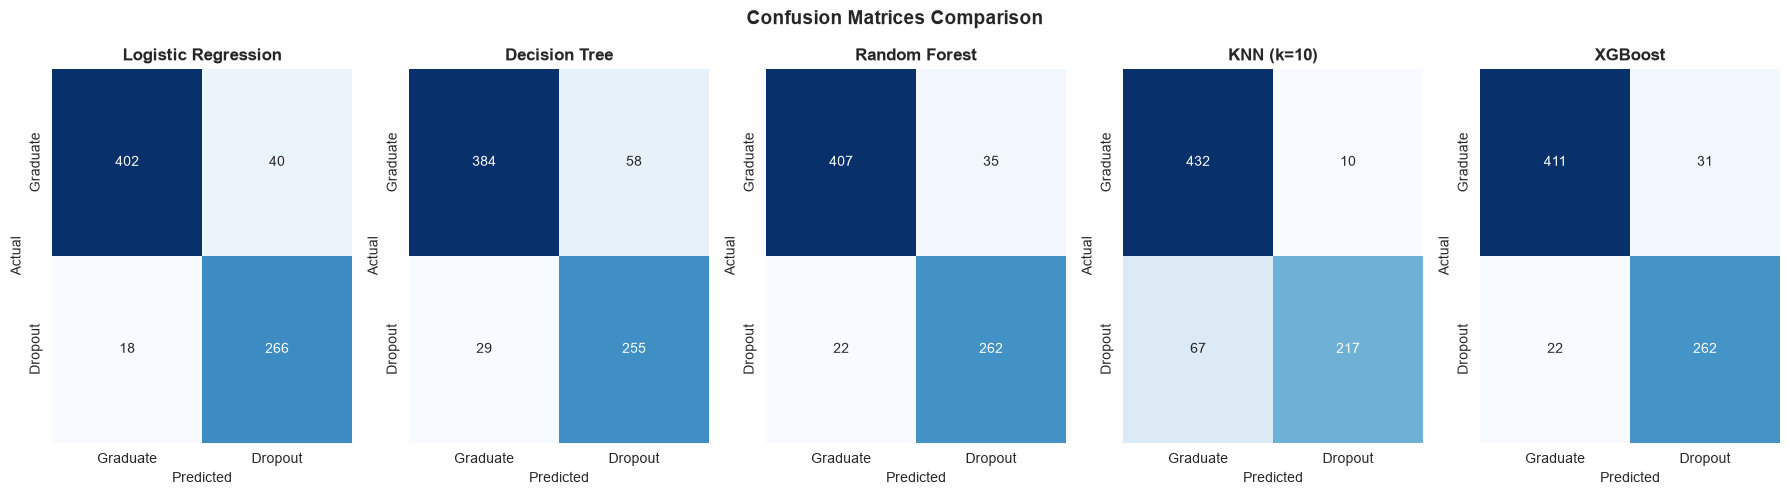

In [23]:
print("\n1. Confusion Matrices...")
plot_confusion_matrices(all_results)

### 4.10.2 ROC Curves


2. ROC Curves...


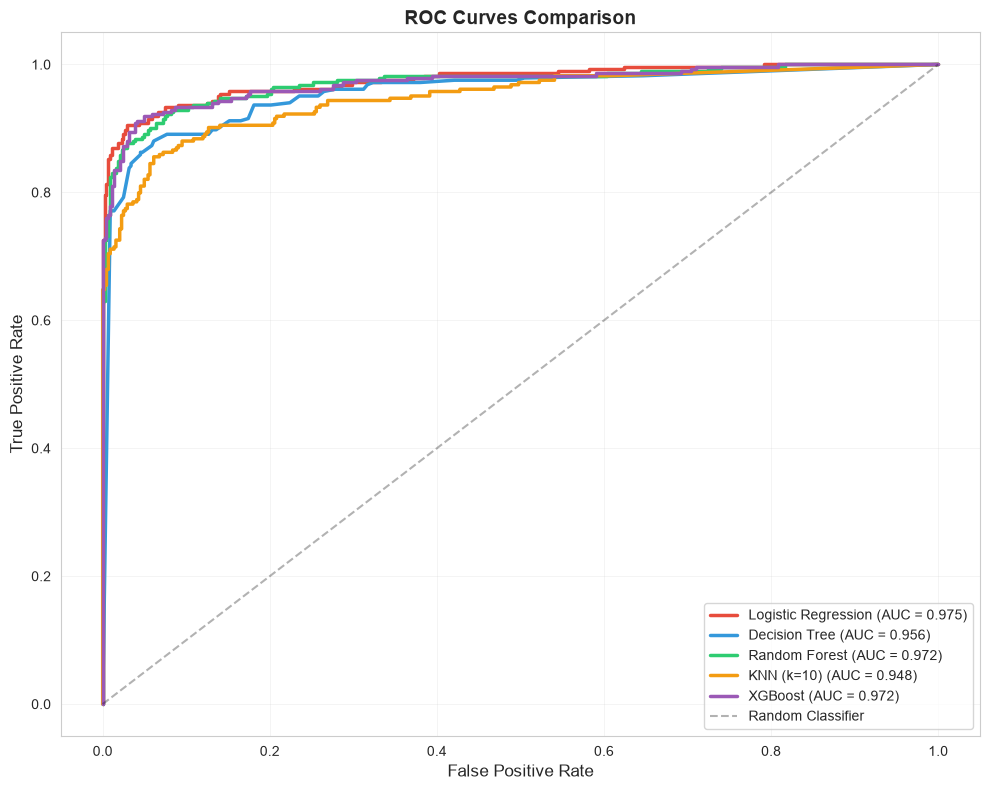

In [24]:
print("\n2. ROC Curves...")
plot_roc_curves(all_results)

### 4.10.3 Metrics Bar Chart


3. Metrics Comparison...


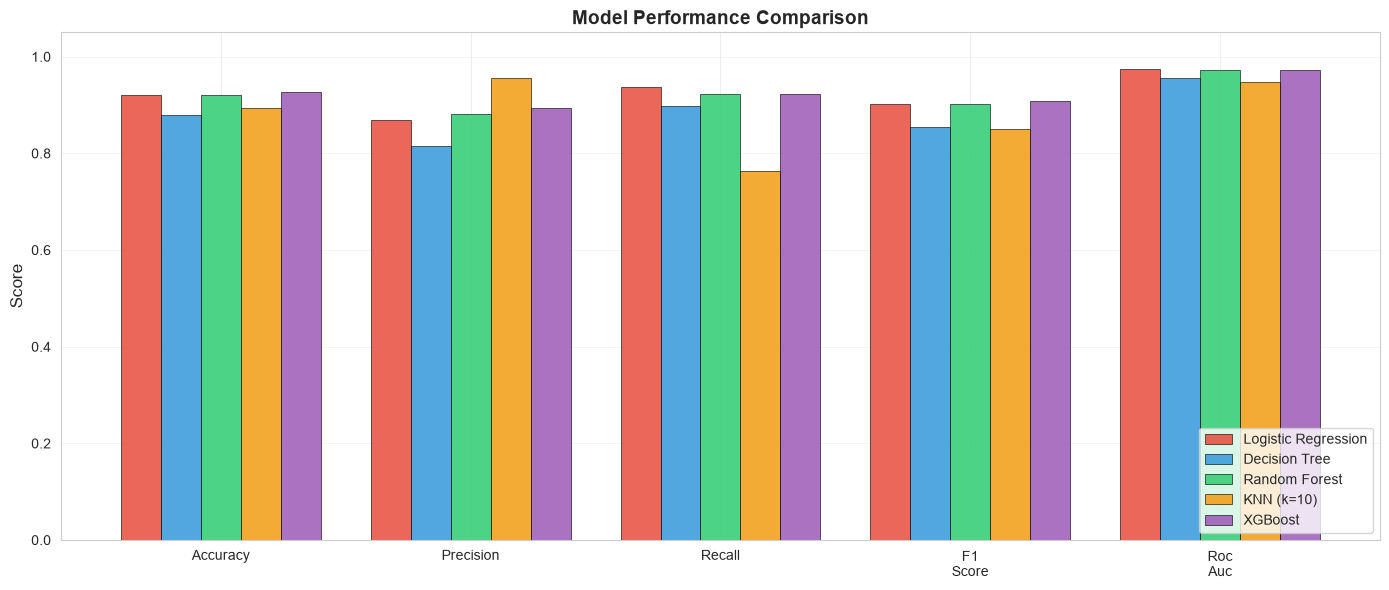

In [25]:
print("\n3. Metrics Comparison...")
plot_metrics_comparison(all_results)

## 4.11 Learning Curves (Best Model)

Learning curves - Random Forest

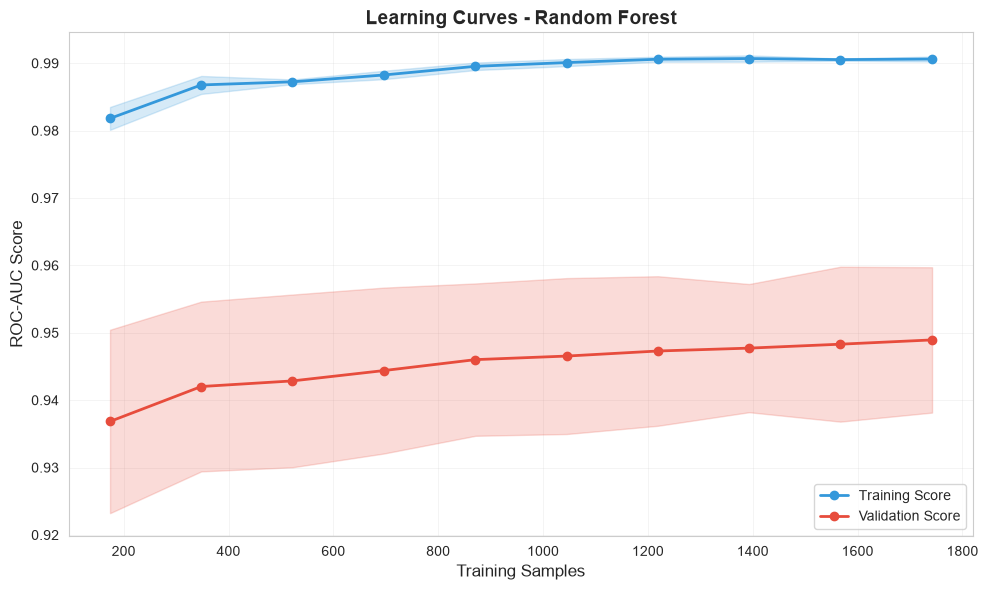

In [26]:
# Generate learning curves for the best model
train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10.0, 6.0))

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#3498db')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#e74c3c')
ax.plot(train_sizes, train_mean, 'o-', color='#3498db', linewidth=2, label='Training Score')
ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', linewidth=2, label='Validation Score')

ax.set_xlabel('Training Samples', fontsize=12)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title('Learning Curves - Random Forest', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.12 Probability Distribution Analysis

Prediction probability distributions

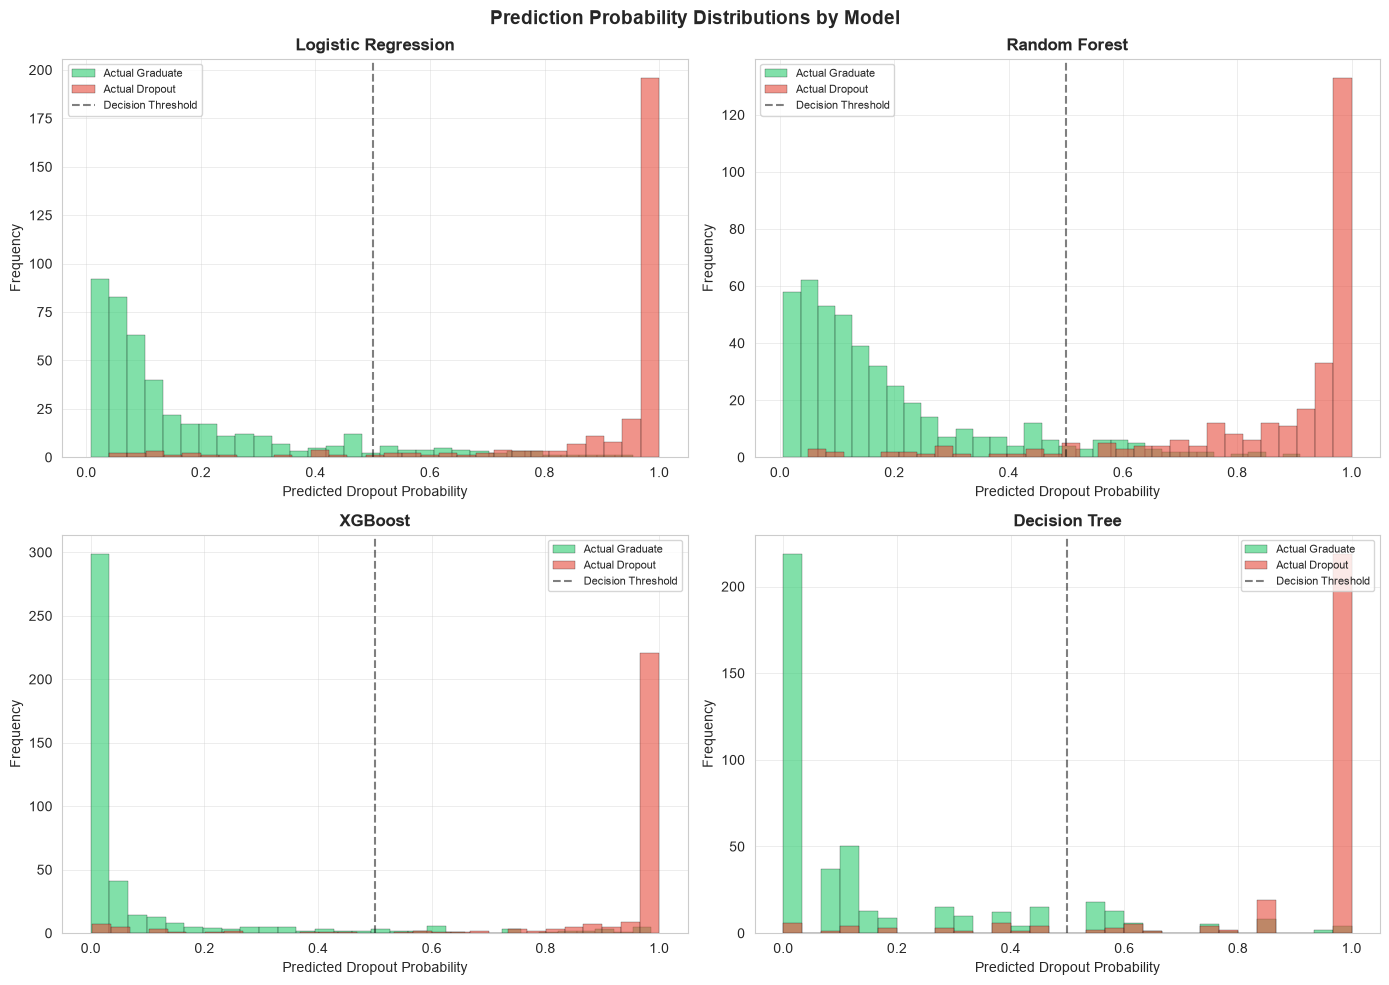

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.0))
axes = axes.flatten()

models_to_plot = [lr_results, rf_results]
if xgb_results is not None:
    models_to_plot.append(xgb_results)
models_to_plot.append(dt_results)

for i, results in enumerate(models_to_plot[:4]):
    ax = axes[i]
    
    # Separate probabilities by actual class
    dropout_probs = results['y_proba'][y_test == 1]
    grad_probs = results['y_proba'][y_test == 0]
    
    ax.hist(grad_probs, bins=30, alpha=0.6, color='#2ecc71', label='Actual Graduate',
            edgecolor='black', linewidth=0.3)
    ax.hist(dropout_probs, bins=30, alpha=0.6, color='#e74c3c', label='Actual Dropout',
            edgecolor='black', linewidth=0.3)
    
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Decision Threshold')
    ax.set_xlabel('Predicted Dropout Probability')
    ax.set_ylabel('Frequency')
    ax.set_title(results['model_name'], fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Prediction Probability Distributions by Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.13 Save models and Results

In [28]:
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

Save all models

In [29]:
models_to_save = {
    'logistic_regression': lr_results['model'],
    'decision_tree': dt_results['model'],
    'random_forest': rf_results['model'],
    'knn': knn_results['model'],
    'scaler': scaler
}

if xgb_results is not None:
    models_to_save['xgboost'] = xgb_results['model']

for name, model in models_to_save.items():
    filepath = models_dir / f'{name}.pkl'
    joblib.dump(model, filepath)
    print(f"  - {name}.pkl")

  - logistic_regression.pkl
  - decision_tree.pkl
  - random_forest.pkl
  - knn.pkl
  - scaler.pkl
  - xgboost.pkl


Save comparison results

In [30]:
comparison_df.to_csv('../models/model_comparison.csv')
print(f"  - model_comparison.csv")

  - model_comparison.csv


Save feature importance

In [31]:
rf_importance.to_csv('../models/feature_importance_rf.csv', index=False)
print(f"  - feature_importance_rf.csv")

  - feature_importance_rf.csv


## 4.14 Summary

In [32]:
# Identify best overall model
best_model_name = comparison_df['ROC-AUC'].idxmax()
best_roc_auc = comparison_df['ROC-AUC'].max()
best_f1 = comparison_df.loc[best_model_name, 'F1-Score']

summary = f"""
PERFORMANCE OVERVIEW
─────────────────────────────────────────────
  Total Models Trained:      {len(all_results)}
  Best Model:                {best_model_name}
  Best ROC-AUC:              {best_roc_auc:.4f}
  Best F1-Score:             {best_f1:.4f}

MODEL RANKINGS (by ROC-AUC)
─────────────────────────────────────────────"""

print(summary)

ranking = comparison_df.sort_values('ROC-AUC', ascending=False)
for i, (model, row) in enumerate(ranking.iterrows(), 1):
    print(f"  {i}. {model:<22s}  ROC-AUC: {row['ROC-AUC']:.4f}  F1: {row['F1-Score']:.4f}")

print(f"   Best model: {best_model_name} (ROC-AUC: {best_roc_auc:.4f})")


PERFORMANCE OVERVIEW
─────────────────────────────────────────────
  Total Models Trained:      5
  Best Model:                Logistic Regression
  Best ROC-AUC:              0.9755
  Best F1-Score:             0.9017

MODEL RANKINGS (by ROC-AUC)
─────────────────────────────────────────────
  1. Logistic Regression     ROC-AUC: 0.9755  F1: 0.9017
  2. Random Forest           ROC-AUC: 0.9716  F1: 0.9019
  3. XGBoost                 ROC-AUC: 0.9716  F1: 0.9081
  4. Decision Tree           ROC-AUC: 0.9559  F1: 0.8543
  5. KNN (k=10)              ROC-AUC: 0.9483  F1: 0.8493
   Best model: Logistic Regression (ROC-AUC: 0.9755)


## Appendi: Quick Prediction Function

In [33]:
def predict_dropout_risk(student_data, model=None, scaler=None, feature_names=None):
    """
    Predict dropout risk for a single student.
    
    Parameters:
    -----------
    student_data : dict or pd.Series
        Student features
    model : sklearn model
        Trained model (defaults to Random Forest)
    scaler : StandardScaler
        Fitted scaler (for logistic regression)
    feature_names : list
        Feature names in correct order
    
    Returns:
    --------
    dict : Prediction and probability
    """
    if model is None:
        model = rf_results['model']
    
    if feature_names is None:
        feature_names = X_train.columns.tolist()
    
    # Convert to DataFrame
    if isinstance(student_data, dict):
        student_df = pd.DataFrame([student_data])
    else:
        student_df = pd.DataFrame([student_data])
    
    # Ensure correct features
    student_df = student_df.reindex(columns=feature_names, fill_value=0)
    
    # Scale if needed
    if scaler is not None:
        student_df = pd.DataFrame(
            scaler.transform(student_df),
            columns=feature_names
        )
    
    # Predict
    proba = model.predict_proba(student_df)[0, 1]
    prediction = model.predict(student_df)[0]
    
    return {
        'prediction': 'Dropout' if prediction == 1 else 'Graduate',
        'dropout_probability': proba,
        'risk_level': 'High' if proba > 0.7 else 'Medium' if proba > 0.4 else 'Low'
    }


print("\nExample prediction (first test sample):")
sample = X_test.iloc[0]
result = predict_dropout_risk(sample, model=rf_results['model'])
print(f"  Prediction: {result['prediction']}")
print(f"  Dropout Probability: {result['dropout_probability']:.1%}")
print(f"  Risk Level: {result['risk_level']}")
print(f"  Actual: {'Dropout' if y_test[0] == 1 else 'Graduate'}")


Example prediction (first test sample):
  Prediction: Graduate
  Dropout Probability: 6.8%
  Risk Level: Low
  Actual: Graduate
